In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
visual = pd.read_csv("Cleaned_Chase_Dataset.csv")
visual.head()

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch Age,Year_Since_Acquisition,Total_Deposits,Growth_%,CAGR
0,JPMorgan Chase Bank,0,Amityville Driveup Branch,174,1954-06-14,1975-01-18,4 John St,Amityville,Suffolk,NY,...,96994.0,118907.0,115708.0,120730.0,125922,72,51,763639.0,35.245849,5.160826
1,JPMorgan Chase Bank,0,Babylon Branch,176,1955-07-03,1975-01-18,31 West Main Street,Babylon,Suffolk,NY,...,261589.0,289395.0,281756.0,292377.0,314562,71,51,1964359.0,20.072831,3.095757
2,JPMorgan Chase Bank,0,Center Moriches Main St Branch,178,1955-07-11,1975-01-18,366 Main St,Center Moriches,Suffolk,NY,...,115658.0,116485.0,119196.0,124078.0,125948,71,51,819186.0,14.900333,2.341917
3,JPMorgan Chase Bank,0,Deer Park Grand Blvd Branch,184,1965-01-21,1975-01-18,615 Grand Boulevard,Deer Park,Suffolk,NY,...,172441.0,186840.0,194550.0,211782.0,245797,61,51,1336368.0,51.816509,7.206183
4,JPMorgan Chase Bank,0,East Northportlarkfield Rd Branch,186,1950-04-11,1975-01-18,271 Larkfield Road,East Northport,Suffolk,NY,...,113899.0,121359.0,128286.0,129058.0,135773,76,51,854624.0,20.549952,3.163921


In [5]:
#Who dominates deposits?
#Who is growing fastest?
inst_summary = visual.groupby('Institution Name').agg({
    'Total_Deposits': 'sum',
    'Growth_%': 'mean'
    }).sort_values(by='Total_Deposits', ascending=False).reset_index()
inst_summary.head()



,Institution Name,Total_Deposits,Growth_%
0,JPMorgan Chase Bank,3.865435e+09,80.397892


In [9]:
#Which Branch Name / Branch Number are top vs weak?
top_branches = visual.sort_values(by='Total_Deposits', ascending=False).head(10)

low_branches = visual.sort_values(by='Total_Deposits').head(10)  
visual[['Branch Name', 'Total_Deposits']].head(10)

,Branch Name,Total_Deposits
0,Amityville Driveup Branch,763639.0
1,Babylon Branch,1964359.0
2,Center Moriches Main St Branch,819186.0
3,Deer Park Grand Blvd Branch,1336368.0
4,East Northportlarkfield Rd Branch,854624.0
5,Bar Harbour Branch,1220910.0
6,Melville Branch,1457029.0
7,North Bellmore Branch,936359.0
8,Northport Main St Branch,950349.0
9,Riverhead Shopping Center Branch,236739.0


In [11]:
#Which states = strong markets
#Which states = declining
state_summary = visual.groupby('State').agg({
    'Total_Deposits': 'sum',
    'Growth_%': 'mean'
    }).sort_values(by='Growth_%', ascending=False).reset_index()
state_summary.head()

,State,Total_Deposits,Growth_%
0,GA,5661885.0,188.771319
1,FL,102277942.0,129.691328
2,NV,8376394.0,121.863920
3,UT,46662908.0,121.430125
4,CO,53884828.0,119.070586


In [20]:
#Trend of deposits over time
deposit_cols = [col for col in visual.columns if 'Deposits' in col]


yearly_deposits = visual[deposit_cols].sum().reset_index()
yearly_deposits.head()

,index,0
0,2010 Deposits,396652002.0
1,2011 Deposits,452465957.0
2,2012 Deposits,509359399.0
3,2013 Deposits,561584332.0
4,2014 Deposits,643524715.0


In [15]:
#Underperforming branches
#Possible closure candidates
declining = visual[visual['Growth_%'] < 0]
declining.head()

,Institution Name,Main Office,Branch Name,Branch Number,Established Date,Acquired Date,Street Address,City,County,State,...,2012 Deposits,2013 Deposits,2014 Deposits,2015 Deposits,2016 Deposits,Branch Age,Year_Since_Acquisition,Total_Deposits,Growth_%,CAGR
32,JPMorgan Chase Bank,0,Yankee Stadium Branch,363,1928-10-20,1981-10-26,76 East 161st Street,Bronx,Bronx,NY,...,104552.0,112101.0,116762.0,121525.0,3480,98,45,666610.0,-96.507216,-42.826434
122,JPMorgan Chase Bank,0,Madison Avenue and 64th St Branch,791,1800-01-01,1996-07-14,726 Madison Avenue,New York City,New York,NY,...,689745.0,1031195.0,801473.0,27339.0,18449,226,30,2850454.0,-93.255613,-36.199550
125,JPMorgan Chase Bank,0,First Ave and 44th St Branch,800,1953-12-14,1996-07-14,1 United Nations Plaza,New York City,New York,NY,...,663589.0,668676.0,604426.0,576754.0,575874,73,30,4800480.0,-45.106132,-9.512768
181,JPMorgan Chase Bank,0,Select Direct I Branch,1016,1989-01-08,1996-07-14,"1 Chase Manhattan Plaza, 33rd Floor",New York City,New York,NY,...,162.0,139.0,133.0,118.0,157,37,30,1032.0,-4.848485,-0.824907
260,JPMorgan Chase Bank,0,Madison Waverly Branch,1201,1958-12-22,1996-01-12,2 Waverly Place,Madison,Morris,NJ,...,456855.0,451583.0,427166.0,436239.0,411658,68,30,3744845.0,-10.896537,-1.904497


Deposit Trend over Time

Text(0, 0.5, 'Total Deposits')

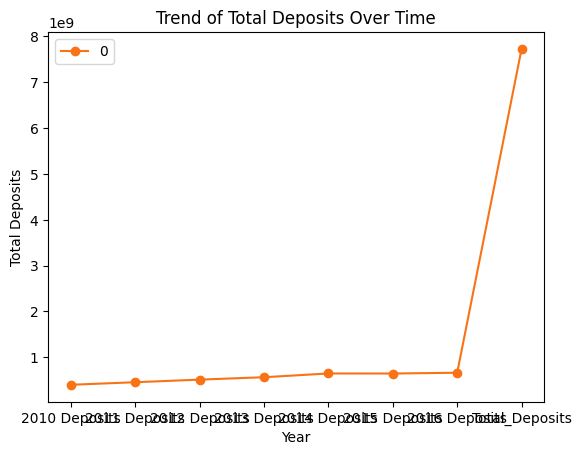

In [ ]:
    yearly_deposits.plot(kind = 'line', x = 'index', y = 0, marker='o', color='#F97316')
    plt.title('Trend of Total Deposits Over Time')
    plt.xlabel('Year')
    plt.ylabel('Total Deposits')
    plt.show()yearly_deposits.plot(kind = 'line', x = 'index', y = 0, marker='o', color='#F97316')

    plt.title('Trend of Total Deposits Over Time')
    plt.xlabel('Year')
    plt.ylabel('Total Deposits')
    plt.show()